In [1]:
from PIL import Image
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from matplotlib import colormaps

colors = ["#E69F00", "#56B4E9", "#009E73", "#D55E00", "#0072B2"]

from astropy.coordinates import SkyCoord, EarthLocation, solar_system_ephemeris, get_body_barycentric, get_body, AltAz
from astropy.time import Time, TimeDelta
from astropy import units as u

import glob
import os
from pathlib import Path
import json

In [2]:
import sys
sys.path.append("~/repos/desioops/py")

In [3]:
from desioops.coordinates import xy_to_altaz

In [4]:
def filename_to_time(fname):
    # At least with files in this format and 24 hour time the timestamp/filename
    # is a monotonically increasing integer.
    if int(fname.replace(".jpg", "")) < 20260216124936:
        shift = TimeDelta(7 * u.hour)
    else:
        shift = 0
        
    year = fname[:4]
    month = fname[4:6]
    day = fname[6:8]

    hour = fname[8:10]
    minute = fname[10:12]
    second = fname[12:14]
    tstring = f"{year}-{month}-{day}T{hour}:{minute}:{second}"
    return Time(tstring, scale="utc") + shift

def load_image(fname):
    return np.array(Image.open(fname))

In [5]:
curr_file = "done/20260817034417.jpg"
im = load_image(curr_file)
time = filename_to_time(curr_file[5:])

# blindly assume that the image is centered
mid = np.array((im.shape[1] / 2, im.shape[0] / 2))
mid

array([4788., 3194.])

In [6]:
projections = {"equidistant": lambda x: x, "orthographic": lambda x: np.sin(x),
               "stereographic": lambda x: 2 * np.tan(x / 2),
               "equisolid": lambda x: 2 * np.sin(x / 2)}
reverse_projections = {"equidistant": lambda x: x, "orthographic": lambda x: np.arcsin(x),
                       "stereographic": lambda x: 2 * np.arctan(x / 2),
                       "equisolid": lambda x: 2 * np.arcsin(x / 2) }

def altaz_to_xy(alt, az, proj, f, dtheta):
    az_corrected = np.array(az, copy=True) + dtheta

    r = f * projections[proj](np.deg2rad(90 - alt))
    x = -np.sin(np.deg2rad(az_corrected)) * r
    y = -np.cos(np.deg2rad(az_corrected)) * r

    return x, y

In [7]:
with open("best_fit.json", "r") as f:
    fit_params = json.load(f)

In [8]:
fit_params

{'equidistant': 2156.2842043174205,
 'orthographic': 3045.6749558272236,
 'stereographic': 1777.31493818144,
 'equisolid': 2344.8937960384155,
 'theta': 0.18331319631621995}

In [9]:
loc = EarthLocation.of_site('kpno')
bodies = ["venus", "jupiter", "moon"]

In [10]:
aa_ref = AltAz(location=loc, obstime=time)
all_alt = []
all_az = []
with solar_system_ephemeris.set('builtin'):
    for body in bodies:
        ob = get_body(body, time, loc)
        ob_altaz = ob.transform_to(aa_ref)

        print(f"{body}: {ob_altaz.alt.degree}, {ob_altaz.az.degree}")

        all_alt.append(ob_altaz.alt.degree)
        all_az.append(ob_altaz.az.degree)
all_alt = np.array(all_alt)
all_az = np.array(all_az)

venus: 4.386411511006834, 260.72611772065807
jupiter: -25.126495696415166, 314.16939462251736
moon: 7.059776606589573, 250.70398357082288


In [11]:
x, y = altaz_to_xy(all_alt, all_az, "equisolid", fit_params["equisolid"], np.rad2deg(fit_params["theta"]))

In [12]:
x, y

(array([3186.110078  , 2288.77373315, 3069.2137962 ]),
 array([  -68.36343363, -3229.25954927,   474.75237042]))

In [13]:
rad = fit_params["equisolid"] * projections["equisolid"](np.deg2rad(90 - all_alt))

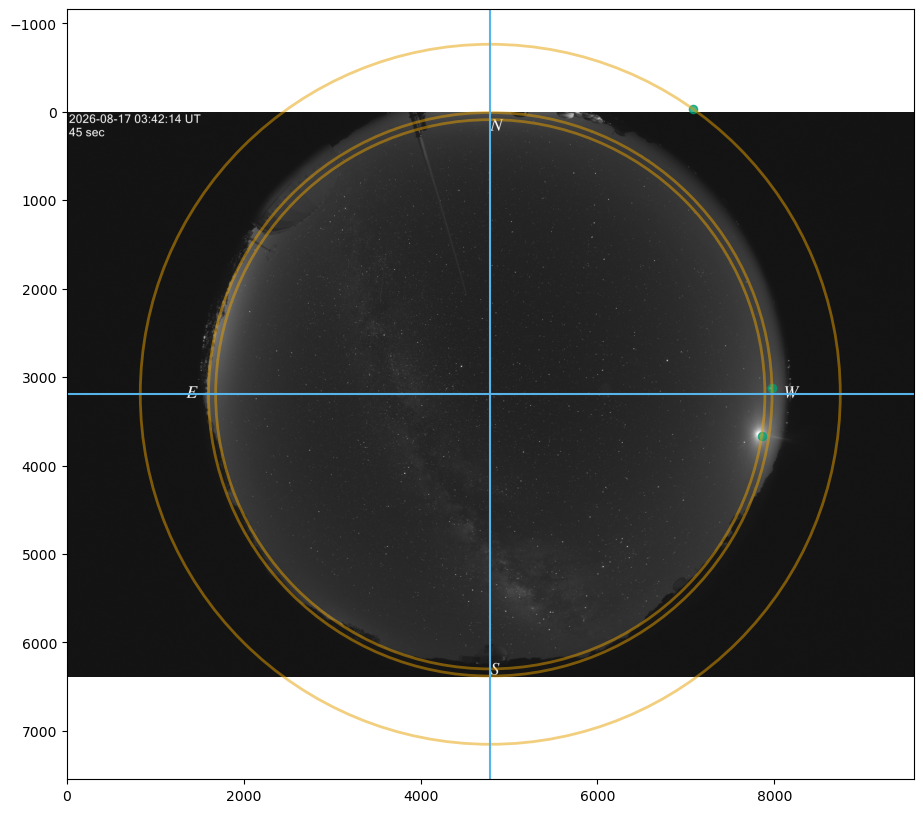

In [14]:
fig, ax = plt.subplots(figsize=(20, 10))

ax.imshow(im, cmap="grey")

ax.axvline(mid[0], c=colors[1])
ax.axhline(mid[1], c=colors[1])

ax.scatter(x + mid[0], y + mid[1], s=35, c=colors[2], alpha=0.75)

for r in rad:
    ax.add_patch(Circle(mid, radius=r, fill=False, lw=2, ec=colors[0], alpha=0.5))


In [182]:
r = 1
az = np.linspace(0, 2 * np.pi, 100)

x = -np.sin(az) * r
y = -np.cos(az) * r

az2 = np.atan2(x, y)
# az2 = np.where(az2 < 0, az2 + 2 * np.pi, az2)

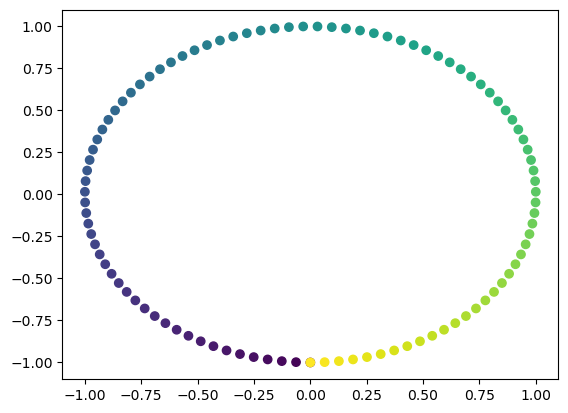

In [185]:
plt.scatter(x, y, c=az)

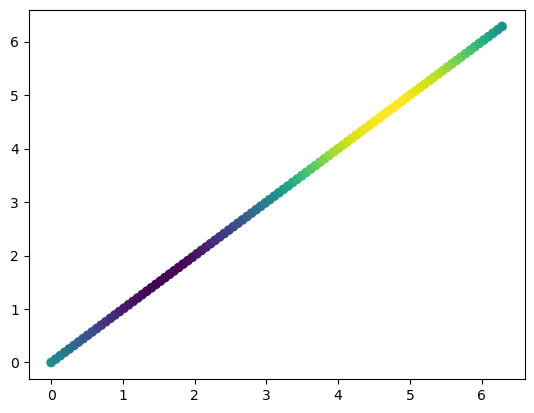

In [186]:
plt.scatter(az, az2 + np.pi, c=x)